# Assemble Text Datasets

This notebook assembles the datasets in a text form so to be used for training LLMs.

## Setup

In [1]:
import os
import sys
from typing import Mapping, Literal, Callable, List, ClassVar, Any, Tuple, Dict
from collections import Counter, defaultdict
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys, rdFMCS, Draw
from rdkit import RDLogger
from rdkit import rdBase
from sklearn.model_selection import train_test_split, GroupShuffleSplit

if 'ipykernel' in sys.modules:
    from tqdm.auto import tqdm  # for notebooks
else:
    from tqdm import tqdm

def safe_display(*args):
    """Displays content only if running in a Jupyter notebook."""
    if 'ipykernel' in sys.modules:
        from IPython.display import display
        display(*args)
    else:
        print(*args)

# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")
blocker = rdBase.BlockLogs()

data_dir = os.path.join(os.getcwd(), 'data')

In [2]:
import sys

sys.path.append(os.path.join(os.getcwd(), 'protac_splitter'))

from protac_splitter.protac_cheminformatics import (
    reassemble_protac,
    check_substructs,
)

In [27]:
ds = {
    'standard': {
        'train': pd.read_csv(os.path.join(data_dir, 'datasets', 'standard', 'train.csv')),
        'test': pd.read_csv(os.path.join(data_dir, 'datasets', 'standard', 'test.csv'))
    },
    'hardest': {
        'train': pd.read_csv(os.path.join(data_dir, 'datasets', 'hardest', 'train.csv')),
        'test': pd.read_csv(os.path.join(data_dir, 'datasets', 'hardest', 'test.csv'))
    },
    'e3_unique': {
        'train': pd.read_csv(os.path.join(data_dir, 'datasets', 'e3_unique', 'train.csv')),
        'test': pd.read_csv(os.path.join(data_dir, 'datasets', 'e3_unique', 'test.csv'))
    },
    'linker_unique': {
        'train': pd.read_csv(os.path.join(data_dir, 'datasets', 'linker_unique', 'train.csv')),
        'test': pd.read_csv(os.path.join(data_dir, 'datasets', 'linker_unique', 'test.csv'))
    },
    'poi_unique': {
        'train': pd.read_csv(os.path.join(data_dir, 'datasets', 'poi_unique', 'train.csv')),
        'test': pd.read_csv(os.path.join(data_dir, 'datasets', 'poi_unique', 'test.csv'))
    }
}

In [28]:
relevant_cols = [c for c in ds['standard']['train'].columns if 'smiles' in c.lower()]
for i, row in ds['standard']['train'][relevant_cols].head().iterrows():
    safe_display(row.to_dict())

{'PROTAC SMILES': 'C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O)NC(C(=O)N3CC(O)CC3C(=O)NC(C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)nc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'E3 Binder SMILES': 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'E3 Binder SMILES with direction': '[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'Linker SMILES': 'COCCOCCOCCN(C)C(=O)CCN',
 'Linker SMILES with direction': '[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1]',
 'POI Ligand SMILES': 'C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'POI Ligand SMILES with direction': '[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O)cc4ccccc34)c(F)c2n1'}

{'PROTAC SMILES': 'C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)N[C@@H](C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)nc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'E3 Binder SMILES': 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'E3 Binder SMILES with direction': '[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'Linker SMILES': 'COCCOCCOCCN(C)C(=O)CCN',
 'Linker SMILES with direction': '[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1]',
 'POI Ligand SMILES': 'C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'POI Ligand SMILES with direction': '[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O)cc4ccccc34)c(F)c2n1'}

{'PROTAC SMILES': 'C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(=O)NC(C(=O)N3CC(O)CC3C(=O)NC(C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)nc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'E3 Binder SMILES': 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'E3 Binder SMILES with direction': '[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'Linker SMILES': 'OCCOCCOCCOCCN(C)C(=O)CCN',
 'Linker SMILES with direction': '[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1]',
 'POI Ligand SMILES': 'C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'POI Ligand SMILES with direction': '[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O)cc4ccccc34)c(F)c2n1'}

{'PROTAC SMILES': 'C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)N[C@@H](C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)nc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'E3 Binder SMILES': 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'E3 Binder SMILES with direction': '[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'Linker SMILES': 'OCCOCCOCCOCCN(C)C(=O)CCN',
 'Linker SMILES with direction': '[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1]',
 'POI Ligand SMILES': 'C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'POI Ligand SMILES with direction': '[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O)cc4ccccc34)c(F)c2n1'}

{'PROTAC SMILES': 'C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCCOCC(=O)NC(C(=O)N3CC(O)CC3C(=O)NC(C)c3ccc(-c4scnc4C)cc3)C(C)(C)C)nc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'E3 Binder SMILES': 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'E3 Binder SMILES with direction': '[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c1ccc(-c2scnc2C)cc1)C(C)(C)C',
 'Linker SMILES': 'OCCOCCOCCOCCOCCN(C)C(=O)CCN',
 'Linker SMILES with direction': '[*:2]OCCOCCOCCOCCOCCN(C)C(=O)CCN[*:1]',
 'POI Ligand SMILES': 'C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)c(Cl)cc23)CC1',
 'POI Ligand SMILES with direction': '[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O)cc4ccccc34)c(F)c2n1'}

In [35]:
def remove_stereo(smiles: str) -> str:
    try:
        mol = Chem.MolFromSmiles(smiles)
        Chem.rdmolops.RemoveStereochemistry(mol)
        return Chem.MolToSmiles(mol)
    except Exception as e:
        # print(e)
        return np.nan

def randomize_smiles(smiles: str) -> str:
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol, canonical=False, doRandom=True)
    except Exception as e:
        # print(e)
        return np.nan


def canonize_smiles(smiles: str) -> str:
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except:
        return np.nan


def levenshtein_distance(s1: str, s2: str) -> int:
    """ Returns the Levenshtein distance between two strings.
    
    Args:
        s1: The first string.
        s2: The second string.
    
    Returns:
        The Levenshtein distance between the two strings.
    """
    # Create a matrix of zeros with dimensions len(s1) + 1 x len(s2) + 1
    matrix = np.zeros((len(s1) + 1, len(s2) + 1))
    # Fill the first row with the index of each character in s1
    for i in range(len(s1) + 1):
        matrix[i, 0] = i
    # Fill the first column with the index of each character in s2
    for j in range(len(s2) + 1):
        matrix[0, j] = j
    # Iterate over the matrix and fill in the values
    for i in range(1, len(s1) + 1):
        for j in range(1, len(s2) + 1):
            # If the characters are the same, the cost is 0
            if s1[i - 1] == s2[j - 1]:
                cost = 0
            else:
                cost = 1
            # Fill in the matrix with the minimum of the three possible values
            matrix[i, j] = min(
                matrix[i - 1, j] + 1,
                matrix[i, j - 1] + 1,
                matrix[i - 1, j - 1] + cost
            )
    # Return the bottom right value of the matrix
    return matrix[-1, -1]


def get_ordered_substruct(
        protac_smiles: str,
        substruct1: str,
        substruct2: str,
) -> Tuple[str, str]:
    """Returns the first substructure that is found in the PROTAC SMILES string.
    
    Args:
        protac_smiles: The PROTAC SMILES string.
        substruct1: The first substructure string.
        substruct2: The second substructure string.

    Returns:
        The first substructure that is found in the PROTAC SMILES string.
    """
    # Remove stereochemistry and attachment points from the SMILES strings
    protac_smiles = remove_stereo(protac_smiles)
    substruct1_nodir = remove_stereo(substruct1).replace('[*:1]', '').replace('[*:2]', '')
    substruct2_nodir = remove_stereo(substruct2).replace('[*:1]', '').replace('[*:2]', '')

    # Remove all digits from the PROTAC SMILES string
    protac_smiles = ''.join([i for i in protac_smiles if not i.isdigit()])
    substruct1_nodir = ''.join([i for i in substruct1_nodir if not i.isdigit()])
    substruct2_nodir = ''.join([i for i in substruct2_nodir if not i.isdigit()])

    # Get a proportion of the PROTAC SMILES string that is the same length as
    # the substructure strings
    protac_sub1 = protac_smiles[:len(substruct1_nodir)]
    protac_sub2 = protac_smiles[:len(substruct2_nodir)]

    # # Check how "similar" the protac_sub1 string is to substruct1_nodir string
    # sub1_sim = sum([1 for i, j in zip(protac_sub1, substruct1_nodir) if i == j]) / len(substruct1_nodir)
    # # Check how "close" the protac_sub2 string is to substruct2_nodir string
    # sub2_sim = sum([1 for i, j in zip(protac_sub2, substruct2_nodir) if i == j]) / len(substruct2_nodir)
    # # Return the substructure that is more similar to the PROTAC SMILES string
    # return substruct1 if sub1_sim > sub2_sim else substruct2

    # Check how "similar" the protac_sub1 string is to substruct1_nodir string
    sub1_dist = levenshtein_distance(protac_sub1, substruct1_nodir)
    sub2_dist = levenshtein_distance(protac_sub2, substruct2_nodir)

    # Return the substructure that is more similar to the PROTAC SMILES string
    if sub1_dist < sub2_dist:
        return substruct1, substruct2
    else:
        return substruct2, substruct1
    

def join_substructures(
        protac_smiles: str,
		e3_smiles: str,
		linker_smiles: str,
		poi_smiles: str,
) -> str:
    """Joins the substructures with the linker to create a PROTAC SMILES string.
    
    Args:
		protac_smiles: The PROTAC SMILES string.
		e3_smiles: The E3 ligand SMILES string.
		linker_smiles: The linker SMILES string.
		poi_smiles: The POI ligand SMILES string.
        
	Returns:
		The PROTAC SMILES string.
	"""
    first_substruct, second_substruct = get_ordered_substruct(protac_smiles, e3_smiles, poi_smiles)
    return f'{first_substruct}.{linker_smiles}.{second_substruct}'


relevant_cols = [c for c in ds['standard']['train'].columns if 'smiles' in c.lower()]
for i, row in ds['standard']['train'][relevant_cols].sample(5, random_state=42).iterrows():
    protac_smiles = row.to_dict()['PROTAC SMILES']
    e3_smiles = row.to_dict()['E3 Binder SMILES with direction']
    linker_smiles = row.to_dict()['Linker SMILES with direction']
    poi_smiles = row.to_dict()['POI Ligand SMILES with direction']
    first_substruct, second_substruct = get_ordered_substruct(protac_smiles, e3_smiles, poi_smiles)

    new_protac, _ = reassemble_protac(
        randomize_smiles(poi_smiles),
        randomize_smiles(linker_smiles),
        randomize_smiles(e3_smiles),
        e3_bond_type='rand_uniform',
        poi_bond_type='rand_uniform',
    )


    # print('PROTAC:', protac_smiles)
    # print('PROTAC:', canonize_smiles(new_protac))
    # print('PROTAC:', new_protac)
    # print('SUBSTRUCT:', f'{first_substruct}.{linker_smiles}.{second_substruct}')
    # print('SUBSTRUCT:', randomize_smiles(f'{first_substruct}.{linker_smiles}.{second_substruct}'))
    # print('SUBSTRUCT:', randomize_smiles(f'{first_substruct}.{linker_smiles}.{second_substruct}'))
    # print('SUBSTRUCT:', randomize_smiles(f'{first_substruct}.{linker_smiles}.{second_substruct}'))
    # safe_display(Chem.MolFromSmiles(protac_smiles))
    # safe_display(Chem.MolFromSmiles(new_protac))
    # safe_display(Chem.MolFromSmiles(randomize_smiles(protac_smiles)))
    # safe_display(Chem.MolFromSmiles(randomize_smiles(protac_smiles)))
    # safe_display(Chem.MolFromSmiles(randomize_smiles(protac_smiles)))
    # safe_display(Chem.MolFromSmiles(first_substruct))
    # print('-' * 80)

## Augmentations

- 20x randomized SMILES per PROTACs


Maximum number of samples: 17
Number of actual combinations: 4,913


0it [00:00, ?it/s]

Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)cc1.[*:2]CCCOCCCCCOCCCCCC[*:1].[*:1]C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC)C(=O)N(C)CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](C(C)C)C(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@H](C)C(=O)N(C)[C@@H](CC(C)C)C(=O)N(C)[C@@H](CC(C)C)C(=O)N(C)[C@@H](C(C)C)C(=O)N1C
CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C/C=C/CCCCCCCOCCCCCOCCC#CNC(=O)CC(NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)c2ccc(-c3scnc3C)cc2)N(C)C(=O)[C@H](C(C)C)N(C)C(=O)[C@H](CC(C)C)N(C)C(=O)[C@H](CC(C)C)N(C)C(=O)[C@@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CC(C)C)N(C)C(=O)[C@H](C(C)C)NC(=O)[C@H](CC(C)C)N(C)C(=O)CN(C)C1=O
C1(N[C@@H](C(C)C)C(=O)N(C)[C@H](C(N[C@@H](C)C(=O)N[C@@H](C(N([C@@H](CC(C)C)C(=O)N(C)[C@H](C(N(C)[C@@H](C(C)C)C(=O)N([C@@H]([C@H](O)[C@H](C)C/C=C/CCCCCCCOCCCCCOCCC#CNC(=O)CC(NC(=O)C2N(C(=O)C(NC(C3(F)CC3)=O)C(C)(C)C)CC(C2)O)c2ccc(cc2)-c2scnc2C)C(=O)N[C@H](C(N(C)CC(N([C@H]1CC(C)C)C)=O)=O)CC)C)=O)CC(C)C)C)=O)C)=O)CC(C)C)=O


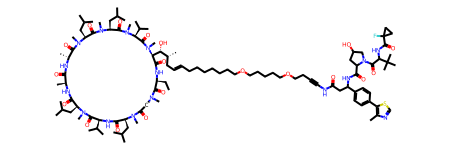

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)cc1.[*:2]CCCOCCCCCOCCCCCC[*:1].[*:1]NS(=O)(=O)c1ccc(Nc2nc(N)n(C(=O)c3sccc3C)n2)cc1
Cc1ccsc1C(=O)n1nc(Nc2ccc(S(=O)(=O)N=CCCCCCOCCCCCOCCCCNC(=O)CC(NC(=O)C3CC(O)CN3C(=O)C(NC(=O)C3(F)CC3)C(C)(C)C)c3ccc(-c4scnc4C)cc3)cc2)nc1N
c1(C)ncsc1-c1ccc(C(CC(NCCCCOCCCCCOCCCCCC=NS(=O)(c2ccc(cc2)Nc2nc(N)n(C(=O)c3sccc3C)n2)=O)=O)NC(=O)C2CC(O)CN2C(C(NC(C2(CC2)F)=O)C(C)(C)C)=O)cc1


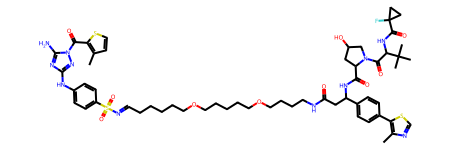

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)cc1.[*:2]CCCOCCCCCOCCCCCC[*:1].[*:1]Cc1c(OC)cc(-c2cn(C)c(=O)c(C)c2C)cc1OC
COc1cc(-c2cn(C)c(=O)c(C)c2C)cc(OC)c1C#CCCCCCOCCCCCOCCCCNC(=O)CC(NC(=O)C1CC(O)CN1C(=O)C(NC(=O)C1(F)CC1)C(C)(C)C)c1ccc(-c2scnc2C)cc1
C1(CC(C(NC(c2ccc(-c3scnc3C)cc2)CC(=O)NCCCCOCCCCCOCCCCCC#Cc2c(OC)cc(cc2OC)-c2c(c(C)c(=O)n(C)c2)C)=O)N(C1)C(=O)C(NC(C1(CC1)F)=O)C(C)(C)C)O


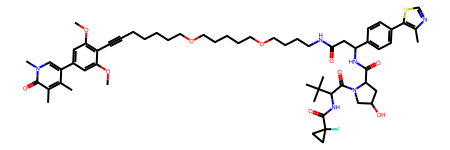

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)cc1.[*:2]CCCOCCCCCOCCCCCC[*:1].[*:1]NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3)cc2)CCC1
Cc1ncsc1-c1ccc(C(CC(=O)NCCCCOCCCCCOCCCCCCNC2(c3ccc(-c4nc5ccn6c(=O)[nH]nc6c5cc4-c4ccccc4)cc3)CCC2)NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)cc1
C(CCOCCCCNC(CC(NC(=O)C1CC(O)CN1C(C(NC(C1(CC1)F)=O)C(C)(C)C)=O)c1ccc(-c2scnc2C)cc1)=O)CCOCCCCCCNC1(c2ccc(cc2)-c2nc3ccn4c(=O)[nH]nc4c3cc2-c2ccccc2)CCC1


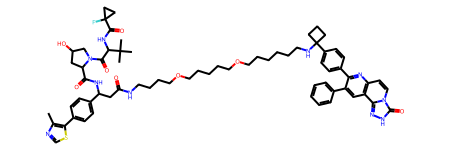

--------------------------------------------------------------------------------
Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)cc1.[*:2]CCCOCCCCCOCCCCCC[*:1].[*:1]CN1CCN(c2ccc(Nc3cc(-c4cccc(-n5ccc6cc(C7CC7)cc(F)c6c5=O)c4CO)cn(C)c3=O)nc2)CC1
Cc1ncsc1-c1ccc(C(CC(=O)NC#CCCOCCCCCOCCCCCC=CN2CCN(c3ccc(Nc4cc(-c5cccc(-n6ccc7cc(C8CC8)cc(F)c7c6=O)c5CO)cn(C)c4=O)nc3)CC2)NC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)cc1
C1C(C(=O)NC(CC(=O)NC#CCCOCCCCCOCCCCCC=CN2CCN(CC2)c2ccc(Nc3c(n(cc(c3)-c3cccc(-n4ccc5c(c(cc(C6CC6)c5)F)c4=O)c3CO)C)=O)nc2)c2ccc(cc2)-c2c(ncs2)C)N(CC1O)C(=O)C(C(C)(C)C)NC(=O)C1(CC1)F


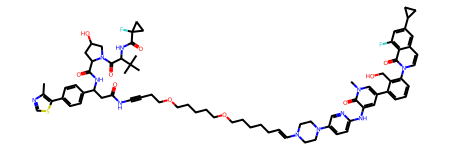

--------------------------------------------------------------------------------


,PROTAC SMILES,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
0,CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C/C=C/CCC...,Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN...,[*:2]CCCOCCCCCOCCCCCC[*:1],[*:1]C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@...
1,Cc1ccsc1C(=O)n1nc(Nc2ccc(S(=O)(=O)N=CCCCCCOCCC...,Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN...,[*:2]CCCOCCCCCOCCCCCC[*:1],[*:1]NS(=O)(=O)c1ccc(Nc2nc(N)n(C(=O)c3sccc3C)n...
2,COc1cc(-c2cn(C)c(=O)c(C)c2C)cc(OC)c1C#CCCCCCOC...,Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN...,[*:2]CCCOCCCCCOCCCCCC[*:1],[*:1]Cc1c(OC)cc(-c2cn(C)c(=O)c(C)c2C)cc1OC
3,Cc1ncsc1-c1ccc(C(CC(=O)NCCCCOCCCCCOCCCCCCNC2(c...,Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN...,[*:2]CCCOCCCCCOCCCCCC[*:1],[*:1]NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3c...
4,Cc1ncsc1-c1ccc(C(CC(=O)NC#CCCOCCCCCOCCCCCC=CN2...,Cc1ncsc1-c1ccc(C(CC(=O)NC[*:2])NC(=O)C2CC(O)CN...,[*:2]CCCOCCCCCOCCCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3cc(-c4cccc(-n5ccc6cc(C7CC...
...,...,...,...,...
4908,CC(C)(C)c1ccc(S(=O)(=O)Nc2ccc(Cl)cc2C(=O)c2cc[...,[*:2]Nc1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,[*:2]N1CCN(c2ccc(C(=O)[*:1])cc2)CC1,[*:1]c1cc(C(=O)c2cc(Cl)ccc2NS(=O)(=O)c2ccc(C(C...
4909,COc1cc(OC)c(Cl)c(NC(=O)N(C)c2cc(Nc3ccc(N4CCN(C...,[*:2]Nc1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,[*:2]N1CCN(c2ccc(C(=O)[*:1])cc2)CC1,[*:1]CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC...
4910,COc1cc2c(cc1-c1c(C)noc1C)[nH]c1nc(C(=O)NCC(=O)...,[*:2]Nc1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,[*:2]N1CCN(c2ccc(C(=O)[*:1])cc2)CC1,[*:1]CNC(=O)c1ncc2c(n1)[nH]c1cc(-c3c(C)noc3C)c...
4911,N#Cc1ccc(O[C@@H]2CCC[C@@H](NC(=O)c3ccc(C(=O)c4...,[*:2]Nc1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,[*:2]N1CCN(c2ccc(C(=O)[*:1])cc2)CC1,[*:1]c1ccc(C(=O)N[C@@H]2CCC[C@@H](Oc3ccc(C#N)c...


In [6]:
def get_unique_substructs(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    return {
        'e3': df['E3 Binder SMILES with direction'].unique(),
        'linker': df['Linker SMILES with direction'].unique(),
        'poi': df['POI Ligand SMILES with direction'].unique(),
    }

def get_substruct_prob(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    unique_substructs = get_unique_substructs(df)
    probs = {
        'e3': np.array([1 / df['E3 Binder SMILES with direction'].value_counts()[sub] for sub in unique_substructs['e3']]),
        'linker': np.array([1 / df['Linker SMILES with direction'].value_counts()[sub] for sub in unique_substructs['linker']]),
        'poi': np.array([1 / df['POI Ligand SMILES with direction'].value_counts()[sub] for sub in unique_substructs['poi']]),
    }
    # Normalize the probabilities so that they sum to 1
    return {k: v / v.sum() for k, v in probs.items()}

unique_substructs = get_unique_substructs(ds['standard']['train'])
max_combinations = 5_000
max_samples = int(max_combinations**(1/3))

probs = get_substruct_prob(ds['standard']['train'])
combinations = product(
    np.random.choice(unique_substructs['e3'], min(max_samples, unique_substructs['e3'].size), replace=False, p=probs['e3']),
    np.random.choice(unique_substructs['linker'], min(max_samples, unique_substructs['e3'].size), replace=False, p=probs['linker']),
    np.random.choice(unique_substructs['poi'], min(max_samples, unique_substructs['e3'].size), replace=False, p=probs['poi']),
)

max_combinations = min(max_samples, unique_substructs['e3'].size) * min(max_samples, unique_substructs['e3'].size) * min(max_samples, unique_substructs['e3'].size)
print(f'Maximum number of samples: {max_samples}')
print(f'Number of actual combinations: {max_combinations:,}')

augmented_df = []
for i, (e3, linker, poi) in tqdm(enumerate(combinations)):
    new_protac = None
    while not new_protac:
        try:
            new_protac, _ = reassemble_protac(
                poi,
                linker,
                e3,
                e3_bond_type='rand_uniform',
                poi_bond_type='rand_uniform',
            )
        except:
            pass
    if new_protac in ds['standard']['test']['PROTAC SMILES'].values:
        continue

    augmented_df.append({
        'PROTAC SMILES': new_protac,
        'E3 Binder SMILES with direction': e3,
        'Linker SMILES with direction': linker,
        'POI Ligand SMILES with direction': poi,
    })
    if i < 5:
        print(f'{e3}.{linker}.{poi}')
        print(new_protac)
        print(randomize_smiles(new_protac))
        safe_display(Chem.MolFromSmiles(new_protac))
        print('-' * 80)

augmented_df = pd.DataFrame(augmented_df)
safe_display(augmented_df)

## Text Datasets

In [38]:
text_ds = {}
for config_name, datasets in ds.items():
	text_ds[config_name] = {}
	for split, dataset in datasets.items():
		text_df = ds[config_name][split].copy()

		# Add 'labels' column
		tqdm.pandas(desc=f'Joining {config_name} {split} substructures')
		text_df['labels'] = text_df.progress_apply(lambda x: join_substructures(x['PROTAC SMILES'], x['E3 Binder SMILES with direction'], x['Linker SMILES with direction'], x['POI Ligand SMILES with direction']), axis=1)

		# Rename 'PROTAC SMILES' column to 'text'
		text_df = text_df.rename(columns={'PROTAC SMILES': 'text'})

		text_ds[config_name][split] = text_df[['text', 'labels']]

		if split == 'train':
			pass
			# TODO: Add configuration with augmented data

			# TODO: Add configuration with randomized data

			# TODO: Add configuration with augmented and randomized data

			# NOTE: Make sure that all the above configurations have roughly the same number of samples, to better estimate the effect of data augmentations

safe_display(text_ds)

Joining substructures:   0%|          | 0/2744 [00:00<?, ?it/s]

Joining substructures:   0%|          | 0/313 [00:00<?, ?it/s]

Joining substructures:   0%|          | 0/2867 [00:00<?, ?it/s]

Joining substructures:   0%|          | 0/286 [00:00<?, ?it/s]

Joining substructures:   0%|          | 0/2825 [00:00<?, ?it/s]

...

Joining substructures:   0%|          | 0/2874 [00:00<?, ?it/s]

Joining substructures:   0%|          | 0/366 [00:00<?, ?it/s]

Joining substructures:   0%|          | 0/2867 [00:00<?, ?it/s]

Joining substructures:   0%|          | 0/365 [00:00<?, ?it/s]

{'standard': {'train':                                                    text  \
  0     C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...   
  1     C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...   
  2     C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...   
  3     C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...   
  4     C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCCO...   
  ...                                                 ...   
  2739  O=C1CCC(N2Cc3c(CCCCCNC(=O)c4ccc(NC(=O)[C@@H]5N...   
  2740  O=C1CCC(N2Cc3c(NC(=O)CCCCCCCN4CCN(c5ccc(Nc6ncc...   
  2741  O=C1CCC(N2Cc3c(NC(=O)CCCCCCN4CCN(c5ccc(Nc6ncc7...   
  2742  O=C1CCC(N2Cc3c(NC(=O)COCCOCCOCCOCCn4cc(Nc5ncc(...   
  2743  O=C1CCC(N2Cc3c(NC(=O)COCCOCCOCc4cn(CCCC(=O)N5C...   
  
                                                   labels  
  0     [*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...  
  1     [*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...  
  2     [*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...  
  3 

## Hugging Face Datasets

If the data files are well organized in a directory, and a README configuration files is provided, then we can load the datasets directly from disk by _only knowing the directory path_:

In [39]:
from datasets import load_dataset, get_dataset_config_names

# Make text_datasets dir if not exists
dataset_dir = os.path.join(data_dir, 'text_datasets')
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir, exist_ok=True)

config_template = '''- config_name: {config_name}
  data_files:
  - split: train
    path: "{config_name}/train.csv"
  - split: test
    path: "{config_name}/test.csv"
'''

# Create a README.md file
with open(os.path.join(dataset_dir, 'README.md'), 'w') as dataset_config:
    # Write the header of the README.md file
    dataset_config.write('---\n')
    dataset_config.write('configs:\n')

    # TODO: The following needs to be replaced with the text-datasets
    for config_name, datasets in text_ds.items():
        # Write the current config template to the README.md file
        dataset_config.write(config_template.format(config_name=config_name))

        # Create the config directory if it does not exist
        config_dir = os.path.join(dataset_dir, config_name)
        if not os.path.exists(config_dir):
            os.makedirs(config_dir, exist_ok=True)

        # Save the CSV datasets to the config directory
        for split, df in datasets.items():
            df.to_csv(os.path.join(config_dir, f'{split}.csv'), index=False)

    # Close the README.md file
    dataset_config.write('---\n')

for config_name in get_dataset_config_names(dataset_dir):
    print(f'Loading {config_name} dataset:')
    safe_display(load_dataset(dataset_dir, name=config_name))

Loading standard dataset:


DatasetDict({
    test: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 313
    })
    train: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 2744
    })
})

Loading hardest dataset:


DatasetDict({
    test: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 286
    })
    train: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 2867
    })
})

Loading e3_unique dataset:


DatasetDict({
    test: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 365
    })
    train: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 2825
    })
})

Loading linker_unique dataset:


DatasetDict({
    test: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 366
    })
    train: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 2874
    })
})

Loading poi_unique dataset:


DatasetDict({
    test: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 365
    })
    train: Dataset({
        features: ['PROTAC ID', 'PROTAC SMILES', 'E3 Binder ID', 'E3 Binder SMILES', 'E3 Binder SMILES with direction', 'Linker ID', 'Linker SMILES', 'Linker SMILES with direction', 'POI Ligand ID', 'POI Ligand SMILES', 'POI Ligand SMILES with direction'],
        num_rows: 2867
    })
})

## Testing Tokenization

In [7]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

model_name = 'seyonec/PubChem10M_SMILES_BPE_450k'
model_name = 'entropy/roberta_zinc_480m'
# model_name = 'DeepChem/ChemBERTa-10M-MTR' # NOTE: Decoding is wrong, possibly due to missing symbols in the vocabulary

model = AutoModelForMaskedLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model

RobertaForMaskedLM(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(2707, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-13): 14 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [8]:
print(model.config.max_length)
print(model.config.max_position_embeddings)
print(tokenizer.model_max_length)

tokenizer.model_max_length = model.config.max_position_embeddings
print(tokenizer.model_max_length)
print(tokenizer.max_model_input_sizes)

20
512
1000000000000000019884624838656
512
{'roberta-base': 512, 'roberta-large': 512, 'roberta-large-mnli': 512, 'distilroberta-base': 512, 'roberta-base-openai-detector': 512, 'roberta-large-openai-detector': 512}


In [9]:
# Tokenize the top-10 longest PROTAC SMILES strings
df = augmented_df
df = ds['standard']['train']
df = ds['standard']['test']

idx = df['PROTAC SMILES'].str.len().nlargest(10).index
protac_smiles = list(df.loc[idx, 'PROTAC SMILES'])

# Print the length of each PROTAC SMILES string
for i, smiles in enumerate(protac_smiles):
    print(f'{i + 1}: {len(smiles)}')

# Tokenize the PROTAC SMILES strings
tokenized = tokenizer(protac_smiles, return_tensors='pt', padding=True, truncation=True)

# Print the length of the tokenized PROTAC SMILES strings
for i, input_ids in enumerate(tokenized['input_ids']):
    print(f'{i + 1}: {len(input_ids)}')

# Decode the tokenized PROTAC SMILES strings and check if they match the original strings
decoded = tokenizer.batch_decode(tokenized['input_ids'], skip_special_tokens=True)
for i, (smiles, dec) in enumerate(zip(protac_smiles, decoded)):
    print(f'{i + 1}: {smiles == dec}')
    if not smiles == dec:
        print(f'Original: {smiles}')
        print(f'Decoded:  {dec}')

1: 236
2: 227
3: 219
4: 213
5: 212
6: 212
7: 209
8: 205
9: 200
10: 190
1: 167
2: 167
3: 167
4: 167
5: 167
6: 167
7: 167
8: 167
9: 167
10: 167
1: True
2: True
3: True
4: True
5: True
6: True
7: True
8: True
9: True
10: True


In [13]:
from transformers import AutoTokenizer, EncoderDecoderModel
from typing import Optional

def get_model(
    pretrained_encoder: str = "seyonec/ChemBERTa-zinc-base-v1",
    pretrained_decoder: str = "seyonec/ChemBERTa-zinc-base-v1",
    max_length: Optional[int] = 512,
    tie_encoder_decoder: bool = False,
):
    
    commit_hash = '0ba58478f467056fe33003d7d91644ecede695a7'
    bert2bert = EncoderDecoderModel.from_encoder_decoder_pretrained(
        pretrained_encoder,
        pretrained_decoder,
        tie_encoder_decoder=tie_encoder_decoder,
        trust_remote_code=True,
        revision=commit_hash,
    )
    print(f"Number of parameters: {bert2bert.num_parameters():,}")
    tokenizer = AutoTokenizer.from_pretrained(pretrained_encoder)
    # Tokenizer configs
    bert2bert.config.decoder_start_token_id = tokenizer.cls_token_id
    bert2bert.config.eos_token_id = tokenizer.sep_token_id
    bert2bert.config.pad_token_id = tokenizer.pad_token_id
    bert2bert.config.vocab_size = bert2bert.config.encoder.vocab_size
    # Generation configs
    # NOTE: See full list of configurations can be found here: https://huggingface.co/docs/transformers/v4.33.3/en/main_classes/text_generation#transformers.GenerationConfig
    bert2bert.encoder.config.max_length = max_length
    bert2bert.decoder.config.max_length = max_length
    # bert2bert.config.min_length = 20

    # # NOTE: Never sample, i.e., always return the token w/ highest probability
    bert2bert.config.do_sample = False
    # bert2bert.config.do_sample = True
    # bert2bert.config.num_beams = 5
    # bert2bert.config.top_k = 20
    
    # bert2bert.config.max_new_tokens = 514
    # bert2bert.config.early_stopping = True
    # bert2bert.config.length_penalty = 2.0
    # # bert2bert.config.no_repeat_ngram_size = 3 # Default: 0
    
    return bert2bert


model_name = 'seyonec/PubChem10M_SMILES_BPE_450k'

bert2bert = get_model(
    pretrained_encoder=model_name,
    pretrained_decoder=model_name,
)
bert2bert

Some weights of the model checkpoint at seyonec/PubChem10M_SMILES_BPE_450k were not used when initializing RobertaModel: ['lm_head.decoder.bias', 'lm_head.decoder.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForCausalLM were not initialized from the model checkpoint at seyonec/PubChem10M_SMILES_BPE_450k and are newly initialized: ['roberta.encoder.layer.1.crossattention.output.dense.bias', 'roberta.encoder.layer.2.crossattention.out

Number of parameters: 181,135,648


EncoderDecoderModel(
  (encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L